# Seasonal Agriculture Performance Analysis
Simple analysis of how farming performance changes across seasons (Kharif, Rabi, Zaid).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 1. Basic Info

In [2]:
df.shape


(4000, 28)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 2. Check for Missing Values and Duplicates

In [4]:
df.isnull().sum()


Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [5]:
# Fill missing values with the average for that crop and season
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Crop', 'Season'])[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum().sum()


np.int64(0)

In [6]:
df.duplicated().sum()


np.int64(0)

## 3. How Many Records per Season?

In [7]:
df['Season'].value_counts()


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

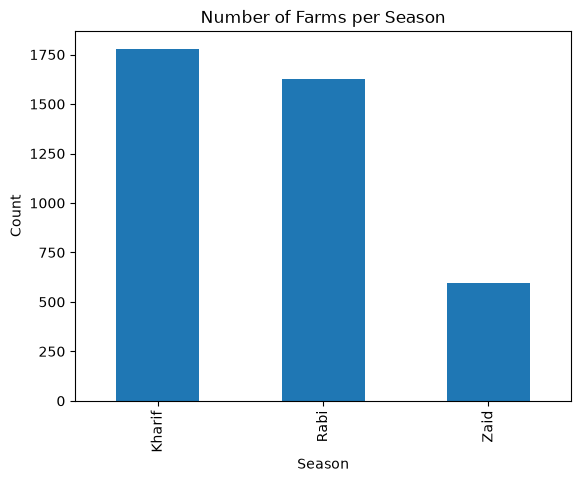

In [8]:
df['Season'].value_counts().plot(kind='bar')
plt.title('Number of Farms per Season')
plt.ylabel('Count')
plt.show()


## 4. Weather Conditions by Season

In [9]:
df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']].mean()


,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,
Kharif,852.103626,28.454019,71.812591
Rabi,435.948156,23.489183,57.893178
Zaid,299.162795,31.042088,52.012121


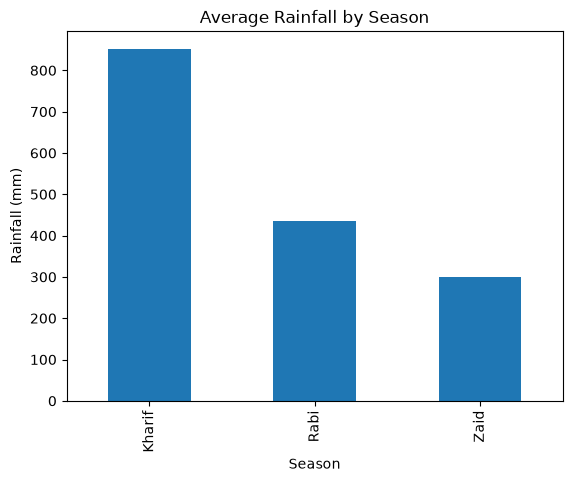

In [10]:
df.groupby('Season')['Rainfall_mm'].mean().plot(kind='bar')
plt.title('Average Rainfall by Season')
plt.ylabel('Rainfall (mm)')
plt.show()


## 5. Yield by Season

In [11]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean()


Season
Kharif    5.630616
Rabi      5.094917
Zaid      4.637340
Name: Yield_Tonnes_Ha, dtype: float64

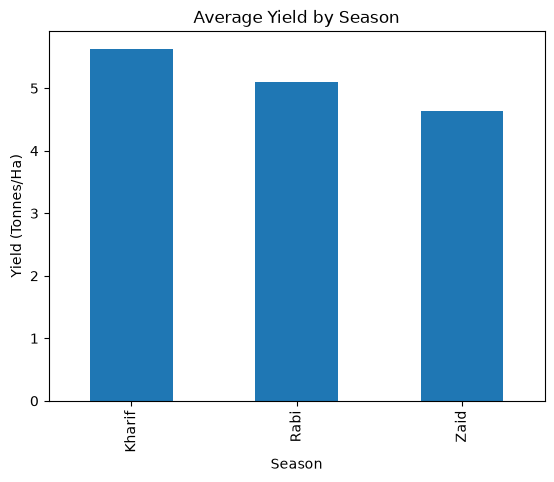

In [12]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean().plot(kind='bar')
plt.title('Average Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()


## 6. Profit by Season

In [13]:
df.groupby('Season')['Profit_INR'].mean()


Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

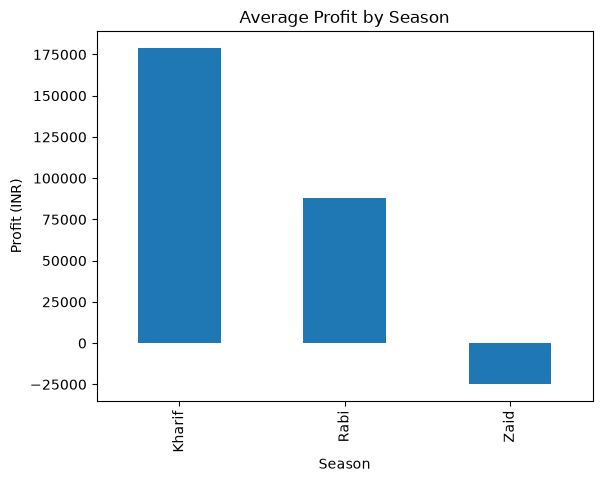

In [14]:
df.groupby('Season')['Profit_INR'].mean().plot(kind='bar')
plt.title('Average Profit by Season')
plt.ylabel('Profit (INR)')
plt.show()


In [15]:
# What percentage of farms lost money in each season?
loss_farms = df[df['Profit_INR'] < 0]
loss_pct = loss_farms.groupby('Season').size() / df.groupby('Season').size() * 100
loss_pct


Season
Kharif    42.214727
Rabi      51.137062
Zaid      64.478114
dtype: float64

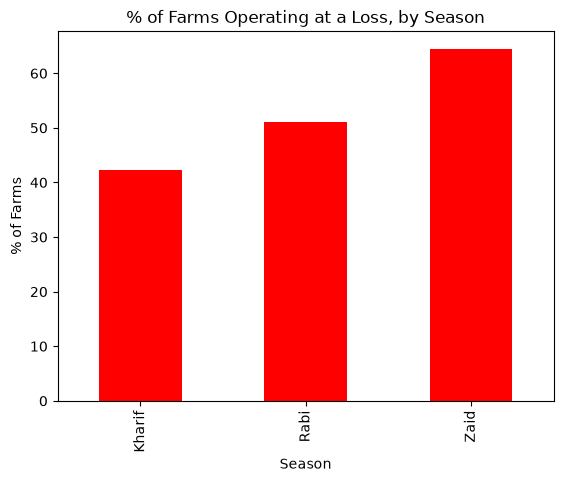

In [16]:
loss_pct.plot(kind='bar', color='red')
plt.title('% of Farms Operating at a Loss, by Season')
plt.ylabel('% of Farms')
plt.show()


## 7. Disease and Pest Risk by Season

In [17]:
df.groupby('Season')['Disease_Pest_Risk_pct'].mean()


Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

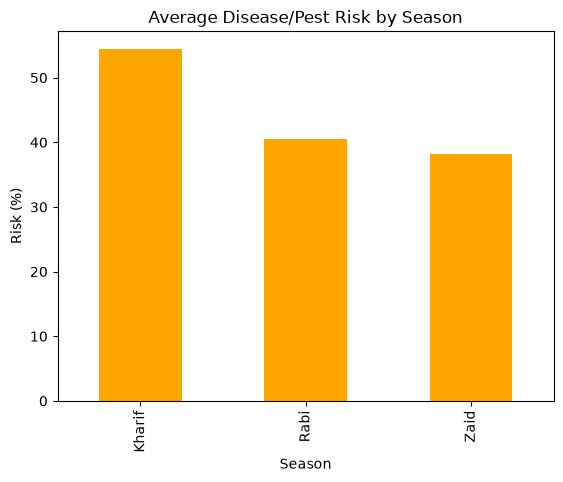

In [18]:
df.groupby('Season')['Disease_Pest_Risk_pct'].mean().plot(kind='bar', color='orange')
plt.title('Average Disease/Pest Risk by Season')
plt.ylabel('Risk (%)')
plt.show()


## 8. Water Usage and Efficiency by Season

In [19]:
df.groupby('Season')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean()


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


## 9. Which Crop Does Best in Which Season?

In [20]:
df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(1)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.7,1.5,1.2
Cotton,1.4,1.2,1.0
Groundnut,1.5,1.2,1.0
Maize,3.0,2.6,2.3
Pulses,1.0,0.9,0.7
Rice,2.7,2.3,1.9
Sugarcane,53.5,44.0,38.4
Wheat,2.3,2.1,1.7


In [21]:
df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').round(0)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


## 10. Correlation Between Yield and Other Factors

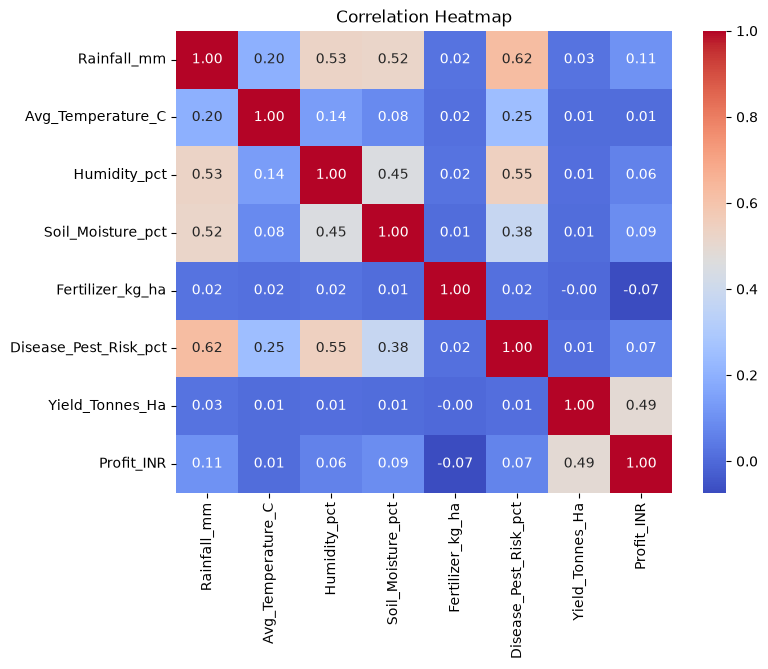

In [23]:


cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
        'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha', 'Profit_INR']

corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
